# Silence trimming before/after
Plot waveforms and mel spectrograms before and after librosa silence trimming for a train audio example.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio, display

from birdclef_2026_ml.notebooks.notebook_utils import init_notebook
from birdclef_2026_ml.paths import load_project_paths
from birdclef_2026_ml.configs import FeatureConfig

paths = load_project_paths()
train_df = pd.read_parquet(paths.train_processed)
feature_cfg = FeatureConfig()

init_notebook()

In [2]:
train_df = pd.read_parquet(paths.train_processed) 
soundscapes = pd.read_parquet(paths.soundscapes_processed)

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_46822/3199465769.py:64: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


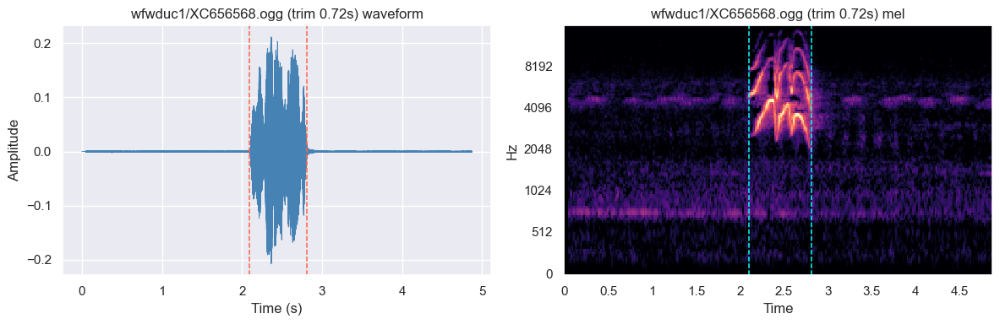

In [3]:
def plot_waveform(ax, y, sr, title, trim_bounds=None):
    times = np.arange(len(y)) / sr
    ax.plot(times, y, color="steelblue", linewidth=0.7)
    if trim_bounds is not None:
        start_s, end_s = trim_bounds
        ax.axvline(start_s, color="tomato", linestyle="--", linewidth=1.1)
        ax.axvline(end_s, color="tomato", linestyle="--", linewidth=1.1)
    ax.set_title(title)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")


def plot_mel(ax, y, cfg, title, trim_bounds=None):
    mel = librosa.feature.melspectrogram(
        y=y,
        sr=cfg.sr,
        n_fft=cfg.n_fft,
        hop_length=cfg.hop_length,
        n_mels=cfg.n_mels,
    )
    mel_db = librosa.power_to_db(mel, ref=1.0)
    img = librosa.display.specshow(
        mel_db,
        sr=cfg.sr,
        hop_length=cfg.hop_length,
        x_axis="time",
        y_axis="mel",
        ax=ax,
    )
    if trim_bounds is not None:
        start_s, end_s = trim_bounds
        ax.axvline(start_s, color="#00FFFF", linestyle="--", linewidth=1.1)
        ax.axvline(end_s, color="#00FFFF", linestyle="--", linewidth=1.1)
    ax.set_title(title)
    return img


def get_trim_bounds(y, sr, top_db=None):
    if top_db is None:
        top_db = getattr(feature_cfg, "trim_top_db", 20)
    trim_y, idx = librosa.effects.trim(y, top_db=top_db)
    start_s = idx[0] / sr
    end_s = idx[1] / sr
    return trim_y, (start_s, end_s)


def plot_audio_pair(axes_row, y, sr, cfg, title_prefix, trim_bounds):
    plot_waveform(axes_row[0], y, sr, f"{title_prefix} waveform", trim_bounds)
    plot_mel(axes_row[1], y, cfg, f"{title_prefix} mel", trim_bounds)


row = train_df.iloc[29658]

raw_path = paths.train_audio_clean_dir / row["filename"]

raw_y, _ = librosa.load(raw_path, sr=feature_cfg.sr)
trim_y, trim_bounds = get_trim_bounds(raw_y, feature_cfg.sr)

display(Audio(raw_y, rate=feature_cfg.sr))
display(Audio(trim_y, rate=feature_cfg.sr))
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
title_prefix = f"{row['filename']} (trim {len(trim_y) / feature_cfg.sr:.2f}s)"
plot_audio_pair(axes, raw_y, feature_cfg.sr, feature_cfg, title_prefix, trim_bounds)
plt.tight_layout()

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_79033/643998149.py:18: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


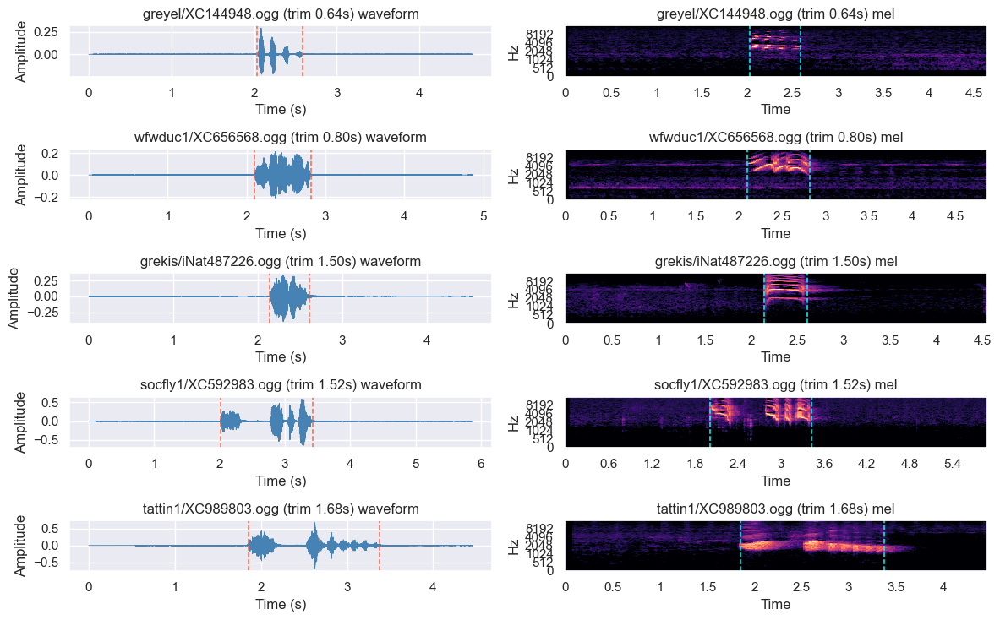

In [47]:
shortest = train_df.nsmallest(5, "duration_trim").reset_index(drop=True)

fig, axes = plt.subplots(
    len(shortest),
    2,
    figsize=(12, 1.5 * len(shortest)),
    constrained_layout=True,
)

for i, row in shortest.iterrows():
    raw_path = paths.train_audio_clean_dir / row["filename"]
    raw_y, _ = librosa.load(raw_path, sr=feature_cfg.sr)
    trim_y, trim_bounds = get_trim_bounds(raw_y, feature_cfg.sr)
    display(Audio(trim_y, rate=feature_cfg.sr))
    title_prefix = f"{row['filename']} (trim {row['duration_trim']:.2f}s)"
    plot_audio_pair(axes[i], raw_y, feature_cfg.sr, feature_cfg, title_prefix, trim_bounds)

plt.tight_layout()
fig.savefig("plots/silence_trim/shortest.pdf", bbox_inches="tight")

/var/folders/dp/qpw35dg90hv8n0247r1klh4c0000gn/T/ipykernel_46822/545161784.py:23: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


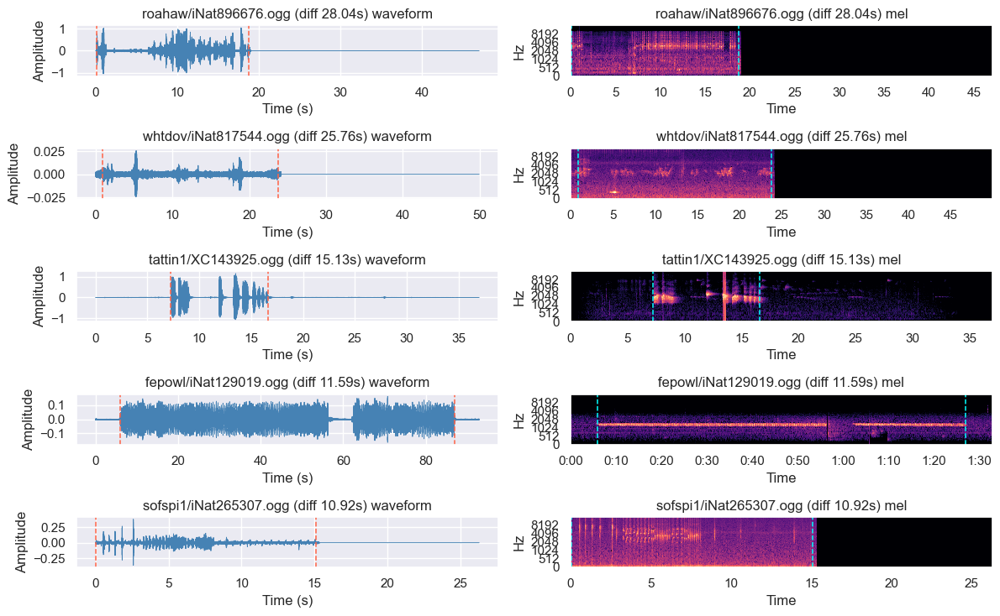

In [4]:
diff = train_df["duration"] - train_df["duration_trim"]
largest_diff = (
    train_df.assign(trim_diff=diff)
    .nlargest(5, "trim_diff")
    .reset_index(drop=True)
 )

fig, axes = plt.subplots(
    len(largest_diff),
    2,
    figsize=(12, 1.5 * len(largest_diff)),
    constrained_layout=True,
)

for i, row in largest_diff.iterrows():
    raw_path = paths.train_audio_clean_dir / row["filename"]
    raw_y, _ = librosa.load(raw_path, sr=feature_cfg.sr)
    trim_y, trim_bounds = get_trim_bounds(raw_y, feature_cfg.sr)
    display(Audio(trim_y, rate=feature_cfg.sr))
    title_prefix = f"{row['filename']} (diff {row['trim_diff']:.2f}s)"
    plot_audio_pair(axes[i], raw_y, feature_cfg.sr, feature_cfg, title_prefix, trim_bounds)

plt.tight_layout()
fig.savefig("plots/silence_trim/largest_diff.pdf", bbox_inches="tight")

In [6]:
print(diff.mean(), np.percentile(diff, 5), np.percentile(diff, 95))

0.3348314408739958 0.0 1.6060781250000016
